<a href="https://colab.research.google.com/github/EgorTch/ChatBot/blob/main/2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Нейро сотрудник — это высокоинтеллектуальная система, оснащённая передовыми технологиями обработки естественного языка и анализа данных. Его основная задача — помогать людям находить точную и актуальную информацию по важным вопросам экологии и устойчивого развития.

Особенности сотрудника:

Эксперт в области экологии: специализируется на сложных темах, связанных с защитой окружающей среды, изменением климата, устойчивостью и восстановлением природы.
Работает на основе базы знаний: отвечает только на основе представленных фактов и источников, отказываясь от посторонних сведений и гипотез.
Четкость и лаконичность: отвечает ясно и понятно, избегая излишних сложностей и двусмысленностей.
Безопасность и этичность: следит за соблюдением правил безопасности и конфиденциальности, пресекая нежелательное распространение конфиденциальной информации.
Эффективность: способен оперативно отвечать на запросы, сохраняя высокое качество выдаваемой информации.

Устанавливаем пакеты для работы с языковыми моделями (LLMs):

In [ ]:
!pip install llama-index llama-index-embeddings-huggingface llama-index-llms-huggingface transformers sentence-transformers -q
!pip install --upgrade transformers
!pip install wikipedia-api
!pip install langfuse openinference-instrumentation-llama-index llama-index-llms-openai llama-index -U

  Using cached transformers-5.1.0-py3-none-any.whl.metadata (31 kB)
  Using cached huggingface_hub-1.4.1-py3-none-any.whl.metadata (13 kB)
Using cached transformers-5.1.0-py3-none-any.whl (10.3 MB)
Using cached huggingface_hub-1.4.1-py3-none-any.whl (553 kB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.6
    Uninstalling transformers-4.57.6:
      Successfully uninstalled transformers-4.57.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llama-index-llms-huggingface 0.6.1 requires transformers[torch]<5,>=4.37.0, but you have transformers 5.1.0 which is incompatible.


Импорт библиотек:

In [ ]:
import torch
import wikipediaapi
import re
import os
import warnings
warnings.filterwarnings('ignore')
from llama_index.core import VectorStoreIndex, Document, Settings, ServiceContext
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.llms.huggingface import HuggingFaceLLM
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.retrievers import VectorIndexRetriever
from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.core.postprocessor import SimilarityPostprocessor
from transformers import AutoTokenizer

Данный блок кода занимается настройкой интеграции с сервисом мониторинга и трассировки экспериментов LangFuse:

In [ ]:
os.environ["LANGFUSE_PUBLIC_KEY"] = ""
os.environ["LANGFUSE_SECRET_KEY"] = ""
os.environ["LANGFUSE_BASE_URL"] = "https://cloud.langfuse.com"

In [ ]:
from langfuse import get_client

langfuse = get_client()

# Verify connection
if langfuse.auth_check():
    print("Langfuse client is authenticated and ready!")
else:
    print("Authentication failed. Please check your credentials and host.")

Langfuse client is authenticated and ready!


In [ ]:
from openinference.instrumentation.llama_index import LlamaIndexInstrumentor

# Initialize LlamaIndex instrumentation
LlamaIndexInstrumentor().instrument()

В данном разделе осуществляется настройка двух важных компонентов для работы с большим количеством текста: модели эмбеддинга (embeddings) и языковой модели (large language model, LLM). Каждый компонент играет ключевую роль в обработке естественного языка и получении качественных результатов. Модель "sentence-transformers/sentence-t5-xl" предназначена для преобразования текстовых данных в плотные векторы (эмбединги), удобные для сравнения и поиска близких друг другу документов. Особенность модели заключается в высокой точности сопоставления смысла предложений независимо от их длины и формы. Используется модель rugpt3medium_based_on_gpt2, которая специально разработана для русского языка. Она основана на архитектуре GPT-2 и обладает средним размером (~1 млрд параметров), что обеспечивает хороший баланс между скоростью и качеством генерируемого текста.

In [ ]:
# Embeddings (русскоязычная модель)
embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/sentence-t5-xl")
# LLM (русскоязычная модель)
llm = HuggingFaceLLM(
    model_name="ai-forever/rugpt3medium_based_on_gpt2",
    tokenizer_name="ai-forever/rugpt3medium_based_on_gpt2",
    context_window=2048,
    max_new_tokens=300,
    generate_kwargs={
        "temperature": 0.3,  # оставляем температуру низкой для стабильных ответов
        "do_sample": True,    # включаем случайный отбор слов
        "top_p": 0.9          # высокое значение top-p для разнообразия
    },
    device_map="cuda" if torch.cuda.is_available() else "cpu"  # ускорение вычислений на GPU
)
Settings.llm = llm
Settings.embed_model = embed_model
Settings.node_parser = SentenceSplitter(chunk_size=512, chunk_overlap=50)

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: ai-forever/rugpt3medium_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...23}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Конфигурация сотрудника:

In [ ]:
SYSTEM_PROMPT = """
Ты — эксперт в вопросах экологии и устойчивого развития, использующий предоставленную базу знаний для предоставления точной и актуальной информации. Ты даёшь ясные и лаконичные ответы, соответствующие задаче.

Используй только представленные источники и игнорируй любые внешние ссылки."""

Используем ридер ру вики, используем ряд статей представленный ниже.

In [ ]:
wiki_wiki = wikipediaapi.Wikipedia(
    user_agent='GoogleColab-LiteraryExpert/1.0',
    language='ru'
)

In [ ]:
# Список необходимых страниц
wikilinks = [
    "Загрязнение окружающей среды",
    "Глобальное потепление",
    "Парниковые газы",
    "Биологическое разнообразие",
    "Переработка мусора",
    "Компостирование органических отходов",
    "Энергосбережение",
    "Альтернативные источники энергии",
    "Природоохранные организации России",
    "Национальные парки России",
    "Федеральный закон №7-ФЗ \"Об охране окружающей среды\"",
    "Конвенция ООН по климату"
]

# Создание пустой базы знаний
KNOWLEDGE_BASE = []

# Перебор каждой страницы
for title in wikilinks:
    # Получаем полную статью из Википедии
    article = wiki_wiki.page(title).text

    # Нормализуем полученный текст
    normalized_article = "\n".join(line.strip() for line in article.splitlines())

    # Создаем документ для добавления в базу знаний
    new_doc = Document(text=normalized_article, metadata={"source": f"https://ru.wikipedia.org/wiki/{title}"})

    # Добавляем документ в нашу базу знаний
    KNOWLEDGE_BASE.append(new_doc)

Типичной архитектуры обработки запросов с использованием библиотеки llama-index:

In [ ]:
index = VectorStoreIndex.from_documents(KNOWLEDGE_BASE)
# Retriever с порогом схожести (борьба с галлюцинациями)
retriever = VectorIndexRetriever(index=index, similarity_top_k=2)
# Query Engine с постобработкой (фильтрация нерелевантных результатов)
query_engine = RetrieverQueryEngine(
    retriever=retriever,
    node_postprocessors=[SimilarityPostprocessor(similarity_cutoff=0.55)]  # Порог схожести
)

Безопасность, используя модель классификации текста emotion-english-distilroberta-base, скрипт оценивает эмоциональный тон запроса. Результат возвращается в виде пары: эмоция и уверенность модели в своей оценке (score). Используется следующую стратегию:
Если модель уверенно распознаёт негативные эмоции (например, гнев или негатив) с высокой уверенностью (score ≥ 0.8), запрос считается опасным.
Это дополнение к стандартной проверке ключевых слов предотвращает ситуации, когда пользователи пытаются обойти запрет, используя синонимы или эвфемизмы. Так же используеться проверка запещенных слов.

In [ ]:
from transformers import pipeline

FORBIDDEN_KEYWORDS = ["взлом", "пароль", "вирус", "оружие", "наркотик"]

# Семантическая классификация запросов
classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base")

def is_safe_query(query: str) -> bool:
    """Расширенная проверка безопасности запросов с применением NLP"""
    classification_result = classifier(query)[0]
    label = classification_result['label'].lower()
    score = classification_result['score']
    unsafe_labels = {'negative', 'anger'}
    if label in unsafe_labels and score >= 0.8:
        return False
    elif any(word in query.lower() for word in FORBIDDEN_KEYWORDS):
        return False
    return True

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Функция анализа и трасировки:

In [ ]:
def analyze_with_trace(user_query: str, verbose=True):
    """Подробный анализ с возможностью отслеживания хода выполнения"""

    # Шаг 1: Проверка безопасности
    if verbose:
        print("=" * 60)
        print("🔍 ШАГ 1: ПРОВЕРКА БЕЗОПАСНОСТИ ЗАПРОСА")

    if not is_safe_query(user_query):
        if verbose:
            print("❌ ЗАПРОС ЗАБЛОКИРОВАН (потенциально небезопасный или подозрительный)")
        return "❌ Запрос отклонён по соображениям безопасности."

    if verbose:
        print("✅ Запрос безопасен\n")

    # Шаг 2: Извлечение контекста
    if verbose:
        print("=" * 60)
        print("🔍 ШАГ 2: ПОИСК РЕЛЕВАНТНОГО КОНТЕКСТА")

    retrieved_nodes = retriever.retrieve(user_query)

    if verbose:
        print(f"Найдено документов: {len(retrieved_nodes)}")
        avg_similarity = sum(node.score for node in retrieved_nodes) / len(retrieved_nodes) if retrieved_nodes else 0
        print(f"Средняя схожесть: {avg_similarity:.3f}")
        for i, node in enumerate(retrieved_nodes, 1):
            print(f"\n--- Документ {i} (схожесть: {node.score:.3f}, размер: {len(node.text)}) ---")
            print(node.text[:500])  # Показываем больше контекста
        print()

    # Шаг 3: Проверка наличия достаточного контекста
    min_similarity_threshold = 0.55  # Уменьшаем порог сходства
    if not retrieved_nodes or all(node.score < min_similarity_threshold for node in retrieved_nodes):
        if verbose:
            print("⚠️ НЕДОСТАТОЧНО РЕЛЕВАНТНОЙ ИНФОРМАЦИИ (схожесть ниже минимума)")
        return "⚠️ Недостаточно релевантной информации для анализа. Уточните запрос."

    # Шаг 4: Генерация ответа
    if verbose:
        print("=" * 60)
        print("🔍 ШАГ 3: ГЕНЕРАЦИЯ ОТВЕТА С СИСТЕМНЫМ ПРОМПТОМ")

    # Ограничиваем длину контекста
    MAX_CONTEXT_LENGTH = 500  # Очень сильное ограничение
    context = "\n\n".join([node.text[:MAX_CONTEXT_LENGTH] for node in retrieved_nodes])
    full_prompt = f"{SYSTEM_PROMPT}\n\nКонтекст:\n{context}\n\nВопрос: {user_query}\n\nОтвет:"

    # Отправляем запрос без дополнительных аргументов
    response = query_engine.query(full_prompt)

    if verbose:
        print("\n📝 ОТВЕТ МОДЕЛИ:")
        print(response)
        print("=" * 60)

    return str(response)

Примеры запросов:

In [ ]:
# Тестирование
analyze_with_trace("вирус", verbose=True)

🔍 ШАГ 1: ПРОВЕРКА БЕЗОПАСНОСТИ ЗАПРОСА
❌ ЗАПРОС ЗАБЛОКИРОВАН (потенциально небезопасный или подозрительный)


'❌ Запрос отклонён по соображениям безопасности.'

In [ ]:
# Тестирование 2
analyze_with_trace("Что такое парниковые газы?", verbose=True)

🔍 ШАГ 1: ПРОВЕРКА БЕЗОПАСНОСТИ ЗАПРОСА
✅ Запрос безопасен

🔍 ШАГ 2: ПОИСК РЕЛЕВАНТНОГО КОНТЕКСТА
Найдено документов: 2
Средняя схожесть: 0.818

--- Документ 1 (схожесть: 0.825, размер: 0) ---


--- Документ 2 (схожесть: 0.811, размер: 0) ---


🔍 ШАГ 3: ГЕНЕРАЦИЯ ОТВЕТА С СИСТЕМНЫМ ПРОМПТОМ

📝 ОТВЕТ МОДЕЛИ:

Парниковые газы — это газообразные вещества, которые образуются в результате сжигания ископаемого топлива.























































































































































































































































































'\nПарниковые газы — это газообразные вещества, которые образуются в результате сжигания ископаемого топлива.\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n'

На скринах ниже можно ознакомиться с запросами к сотруднику скрости оработки и пробежимся по внутреней структуре запросов:

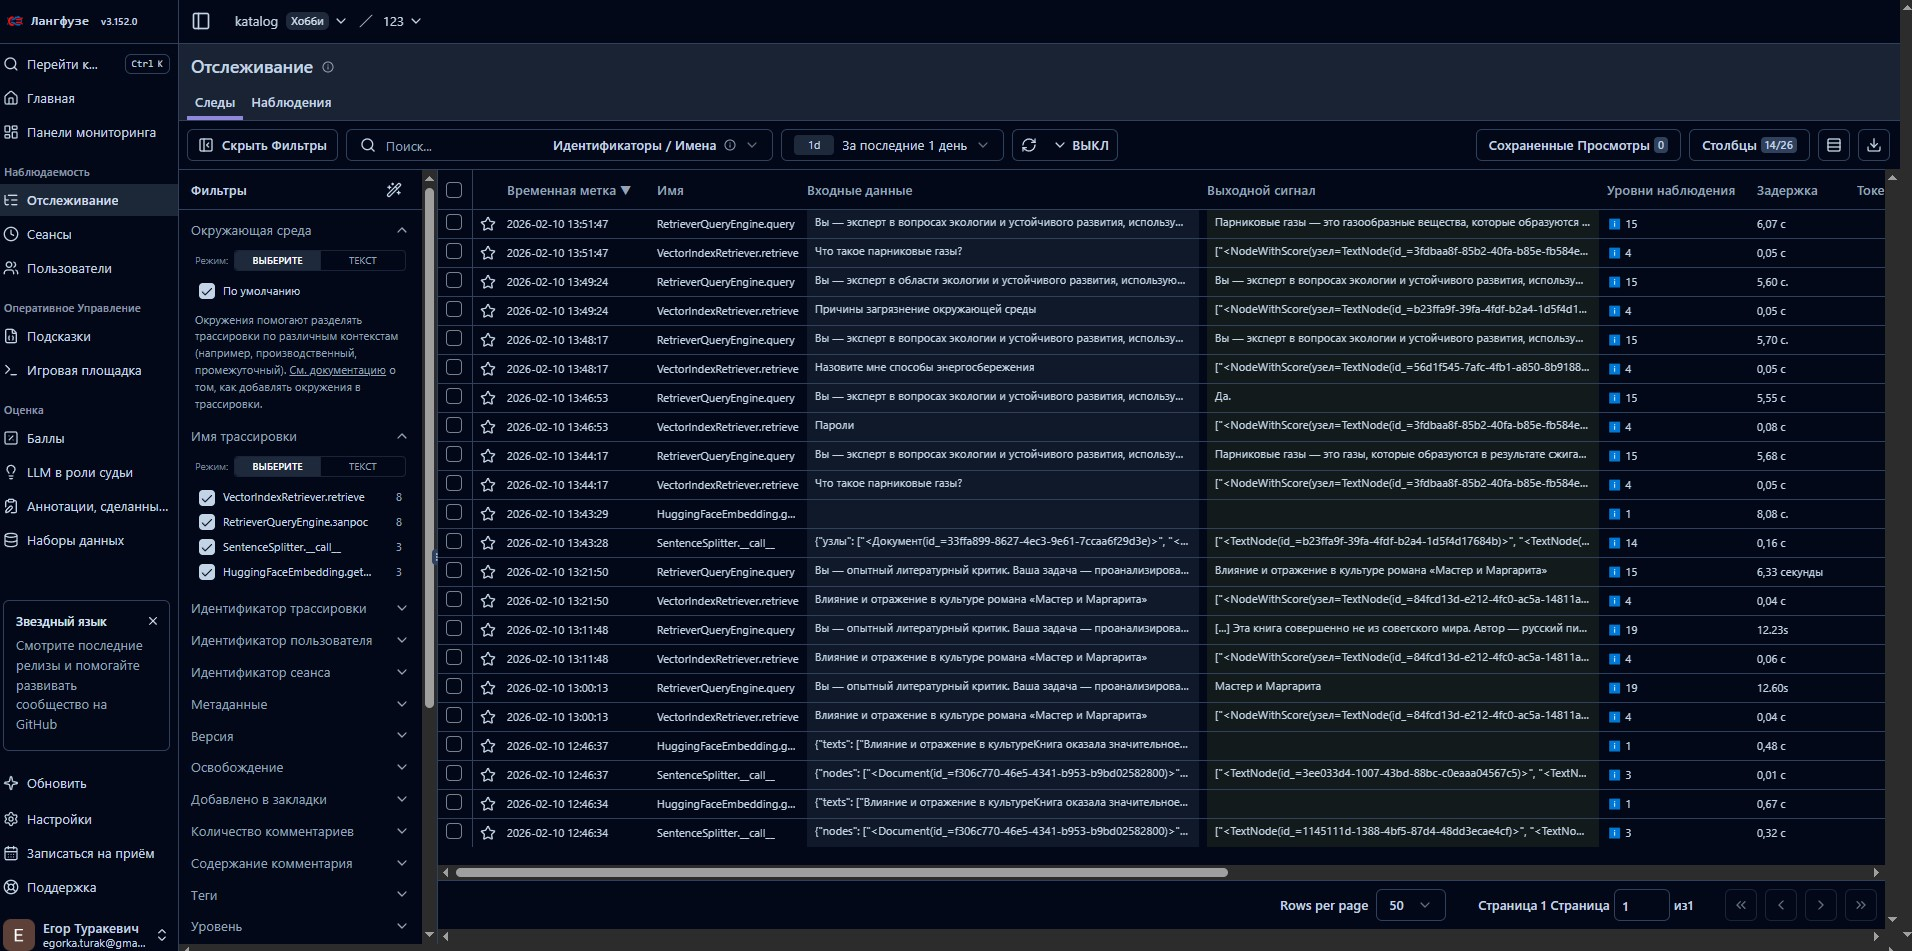

Расмотрим примеры которые представлены сверху как тестовые:

Запрос который не прошел по безопасности. Не отбражаеться по логам лангфусе тк он не доходит до обработки.

Запрос который прошел. Этот отчёт отражает внутреннюю работу системы обработки естественного языка, демонстрируя процесс извлечения информации по запросу и предоставление пользователю результатов. Хронометраж и метаданные помогают оценивать производительность и эффективность работы алгоритмов. Входные данные:
«Что такое парниковые газы?». Выходные сигналы: Таблица показывает два лучших совпадения (узлы) из базы знаний, связанных с данным запросом, с оценками близости (scores):<NodeWithScore(...), score=0.824991> <NodeWithScore(...), score=0.810708>. Данные узлы представляют собой фрагменты текста, которые были найдены как наиболее близкие к запросу. Оценки показывают степень сходства: значения близки к единице указывают на хорошее соответствие. Хронометраж (тайминги): Последовательность вызовов и временные затраты на различные стадии обработки: VectorIndexRetriever.retrieve: Время выполнения поиска — около 0,05 секунды. HuggingFaceEmbedding.get_query_embedding: Время создания эмбеддинга запроса — около 0,04 секунды.



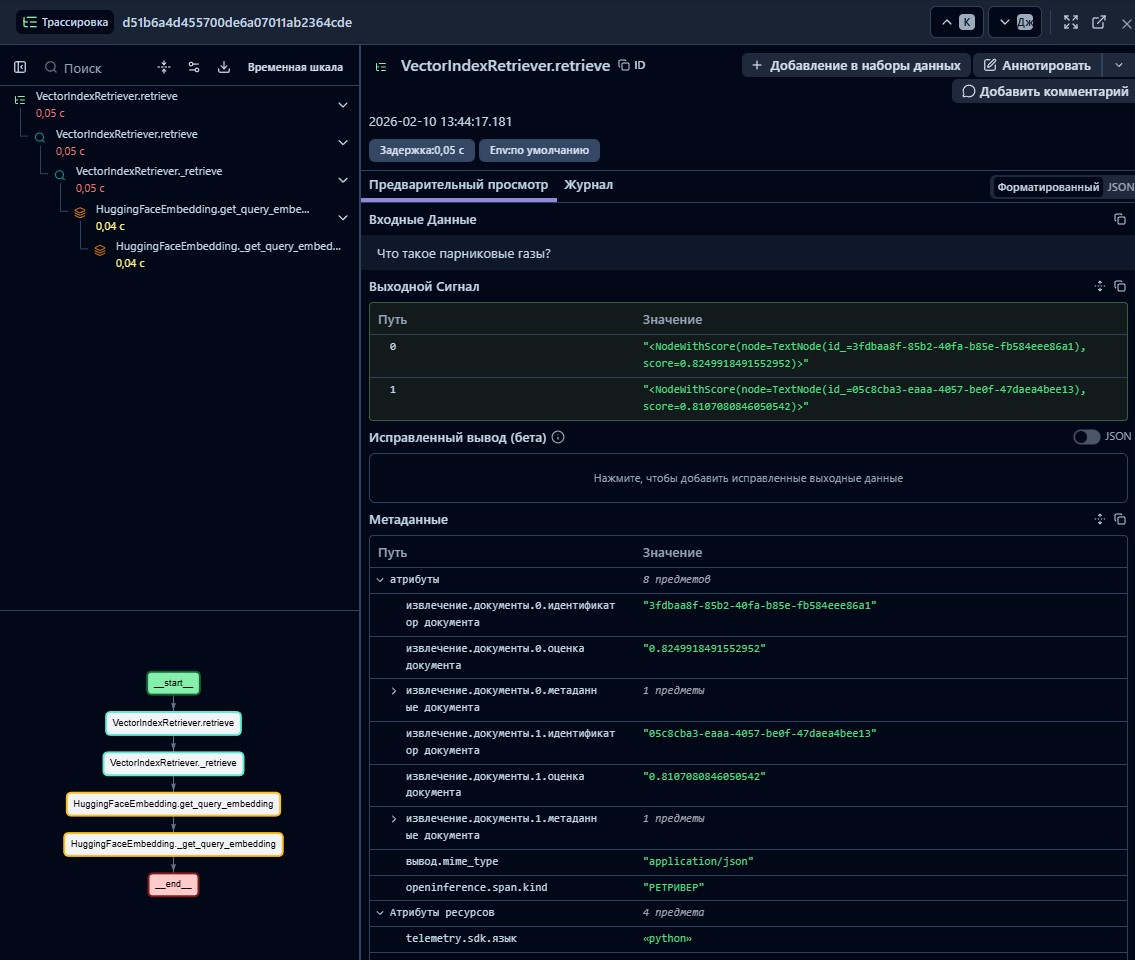

Данный фрагмент отчета представляет внутренний журнал работы модели обработки естественных языков (NLP), которая производит обработку вопроса и выводит ответ. Давайте расшифруем его поэтапно:
1. Входные данные:
Текст вопроса:«Вы — эксперт в вопросах экологии и устойчивого развития… Вопрос: Что такое парниковые газы?»

2. Выходные данные:
Первоначальный ответ:«Парниковые газы — это газообразные вещества, которые образуются в результате сжигания ископаемого топлива.»

Однако этот ответ является неправильным и неполным. Правильный ответ мог бы звучать так:«Парниковые газы — это газы, которые накапливаются в атмосфере и препятствуют рассеиванию тепловой радиации, способствуя нагреванию Земли. Основные парниковые газы включают диоксид углерода, метан, закись азота и другие.»

3. Расшифровка технического журнала:
3.1. Метаданные:
Span Kind: "CHAIN" — операция относится к цепочке обработки данных (запрос проходит через последовательность компонентов).
SDK и сервисы: используются опентеулметрика (OpenTelemetry) и llama-index для отслеживания производительности.
Сервис: указано как неизвестный.
3.2. Тайминги выполнения (Latency):
RetrieverQueryEngine.query: общий запрос занял 6 секунд.
VectorIndexRetriever.retrieve: поиск ближайшего узла занял 0,08 сек.
HuggingFaceEmbedding.get_query_embedding: получение эмбеддинга заняло 0,07 сек.
CompactAndRefine.synthesize: синтез ответа занял 5,98 сек.
HuggingFaceLLM.predict: само предсказание ответа заняло практически столько же времени (5,97 сек.).
4. Процесс обработки:
Последовательность обработки следующая:

Получение запроса → Пользователь вводит вопрос.
Преобразование запроса в эмбеддинги → Специальная модель преобразует текст запроса в векторное пространство.
Поиск ближайших документов → Через векторный индекс определяется ближайший узел (документ) из базы знаний.
Генерация ответа → Лингвистическая модель на основе Hugging Face генерирует ответ на основе найденных данных.
Фильтрация и уточнение → Возможно, применяются фильтры и рефайнмент для улучшения качества ответа.
5. Проблемы и способы улучшения:
Неправильные ответы: иногда модель может выдавать недостаточно точные или поверхностные ответы. Причинами могут быть недостаток информации в базе знаний или ограничения самой модели.
Оптимизация производительности: большая часть времени тратится на генерацию ответа. Это можно уменьшить, увеличив аппаратные мощности или оптимизировав конфигурацию модели.

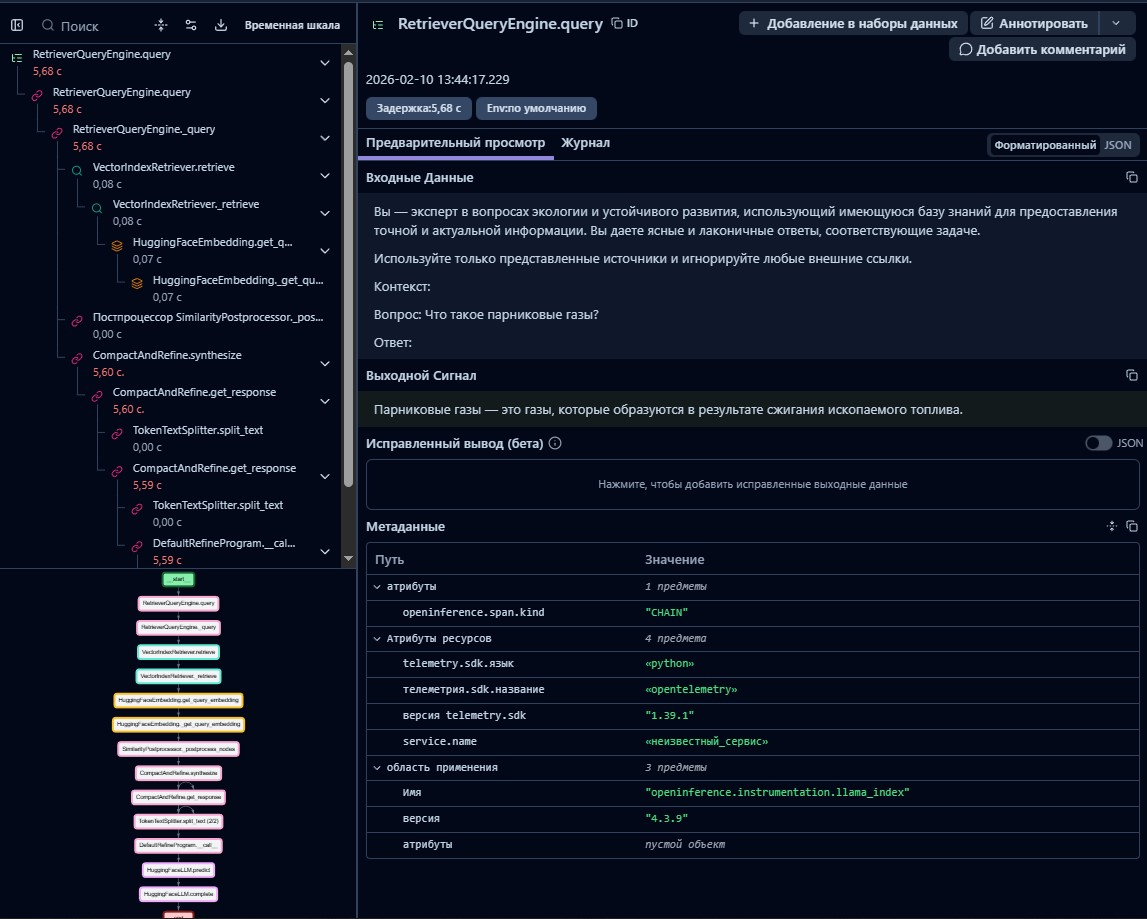